Proyecto_Analitica
Limpieza y organización de datos.

PASO 1: Importar librerias y cargar base de datos

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_financiacion = pd.read_excel('/Users/yedisoncuervo/Downloads/BD taller clasificación (2) (2).xlsx')
df_financiacion.head(5)

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


PASO 2: Informacion general de la base de datos.

In [3]:
df_financiacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  object 
 2   Estado                  21091 non-null  object 
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  object 
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ MB


PASO 3: Validar si hay datos, faltantes, nulos Duplicados.
IMPORTANTE! Realizaremos si la cantidad de datos faltantes en una columna "Variable" supera eld 40% dicha columna será eliminada. 

In [4]:
# ── 4. Datos nulos ────────────────────────────────────────────────────────
print("DATOS NULOS")
nulos = df_financiacion.isnull().sum()
pct   = (nulos / len(df_financiacion) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
if resumen_nulos.empty:
    print("No hay datos nulos.")
else:
    print(resumen_nulos)

DATOS NULOS
                 Nulos  Porcentaje (%)
IngresoEstimado     28            0.13
CapacidadDePago     28            0.13


Dado que el porcentaje  de los datos nulos de las variables (IngresosEstimado/CapacidadDePago) Es de tan solo el 0.13% se procede a eliminar estas filas de nuestra BD.

In [5]:
# Eliminar filas con datos nulos
df_financiacion = df_financiacion.dropna()

In [6]:
# Verificar que quedaron cero nulos
print(f"Filas después de eliminar nulos: {len(df_financiacion)}")
print(f"Nulos restantes: {df_financiacion.isnull().sum().sum()}")

Filas después de eliminar nulos: 21063
Nulos restantes: 0


In [7]:
# ── 5. Datos duplicados ───────────────────────────────────────────────────
print("DATOS DUPLICADOS")
duplicados = df_financiacion.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

DATOS DUPLICADOS
Filas duplicadas: 0


In [8]:
# ── 6. Estadísticas descriptivas ──────────────────────────────────────────
print("ESTADÍSTICAS DESCRIPTIVAS")
print(df_financiacion.describe())

ESTADÍSTICAS DESCRIPTIVAS
               Caso          Edad  ScoreCrediticio  PorcentajeFinanciacion  \
count  2.106300e+04  21063.000000     21063.000000            21063.000000   
mean   1.006178e+09     44.542563       782.361724                0.743488   
std    3.264530e+05     12.744980        85.314167                0.246626   
min    1.004992e+09     19.000000       343.000000                0.100000   
25%    1.005912e+09     34.000000       726.000000                0.552200   
50%    1.006159e+09     43.000000       783.000000                0.800000   
75%    1.006453e+09     54.000000       838.000000                1.000000   
max    1.006786e+09     75.000000       999.000000                1.067000   

              Plazo  IngresoEstimado        Gastos  CapacidadDePago  \
count  21063.000000     2.106300e+04  2.106300e+04     2.106300e+04   
mean      60.633101     5.018901e+06  1.142708e+08    -8.077237e+01   
std       12.497081     5.955286e+06  1.624658e+10     1.1

## IMPORTANTE! 
Con este codigo podremos saber si nuestra variable objetivo esta desbalanceada o no. 

In [9]:
# ── 7. Distribución de la variable objetivo ───────────────────────────────
print("DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)")
conteo = df_financiacion['M3_30AC'].value_counts()
pct_target = (conteo / len(df_financiacion) * 100).round(2)
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct_target}))

DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)
         Conteo  Porcentaje (%)
M3_30AC                        
0         20228           96.04
1           835            3.96


PASO 4: 
## Balanceo de clases

Una vez depurada la base de datos — sin valores nulos, faltantes ni duplicados — se identificó 
un desbalance severo en la variable objetivo `M3_30AC`: el 96% de los registros corresponde 
a clientes sin mora (clase 0) y solo el 4% a clientes con mora (clase 1), lo que representa 
una proporción aproximada de 24:1.

Para mitigar este problema se aplica una estrategia de **undersampling aleatorio**: se conservan 
la totalidad de los 837 registros de la clase minoritaria (clase 1) y se extrae una muestra 
aleatoria de la clase mayoritaria en una proporción 1:2, es decir, 1.674 registros de la 
clase 0.

In [10]:
# ── Balanceo por undersampling (ratio 1:2) ────────────────────────────────
clase_1 = df_financiacion[df_financiacion['M3_30AC'] == 1]
clase_0 = df_financiacion[df_financiacion['M3_30AC'] == 0]

# Muestra aleatoria de clase 0 en proporción 1:2
clase_0_muestra = clase_0.sample(n=len(clase_1) * 2, random_state=42)

# Unir y mezclar
df_balanceado = pd.concat([clase_1, clase_0_muestra]).sample(frac=1, random_state=42).reset_index(drop=True)

# Verificar resultado
print(f"Total registros: {len(df_balanceado)}")
print(f"\nDistribución variable objetivo:")
conteo = df_balanceado['M3_30AC'].value_counts()
pct    = (conteo / len(df_balanceado) * 100).round(2)
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct}))

Total registros: 2505

Distribución variable objetivo:
         Conteo  Porcentaje (%)
M3_30AC                        
0          1670           66.67
1           835           33.33


PASO 5:
Duminización de las variables categoricas

In [11]:
#Revisar las variables candidatas a convertir en dummy
print(df_financiacion['Estado'].value_counts())
print(df_financiacion['Perfil'].value_counts())
print(df_financiacion['Genero'].value_counts())

Estado
NUEVO    16080
USADO     4983
Name: count, dtype: int64
Perfil
ASALARIADO       11588
INDEPENDIENTE     9475
Name: count, dtype: int64
Genero
MASCULINO    11382
FEMENINO      9681
Name: count, dtype: int64


## Lógica de codificación es:

Genero: MASCULINO = 1, FEMENINO = 0
Perfil: ASALARIADO = 1, INDEPENDIENTE = 0
Estado: NUEVO = 1, USADO = 0

In [12]:
# ── Codificación de variables categóricas (binarias) ──────────────────────

df_balanceado['Genero']  = df_balanceado['Genero'].map({'MASCULINO': 1, 'FEMENINO': 0})
df_balanceado['Perfil']  = df_balanceado['Perfil'].map({'ASALARIADO': 1, 'INDEPENDIENTE': 0})
df_balanceado['Estado']  = df_balanceado['Estado'].map({'NUEVO': 1, 'USADO': 0})

# Verificar
print(df_balanceado[['Genero', 'Perfil', 'Estado']].value_counts())

Genero  Perfil  Estado
1       1       1         587
        0       1         438
0       1       1         432
        0       1         359
1       1       0         229
        0       0         162
0       1       0         150
        0       0         148
Name: count, dtype: int64


In [13]:
df_balanceado.head()

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1006446346,1,1,37,1,795,0.9170,60,2388592.0,1573260.21,0.547853,1488231,0
1,1005917646,1,1,35,1,785,1.0112,72,2814350.0,3445278.85,-0.258608,2439711,1
2,1006623892,1,0,34,0,785,1.0000,60,1468462.0,1299911.13,0.108899,1547771,0
3,1006109939,1,1,46,0,816,1.0268,60,1753400.0,1631414.91,0.083970,1452719,1
4,1005989107,1,1,71,0,818,1.0000,72,28641580.0,10610617.88,10.854767,1661110,0


In [14]:
# ── 1. Eliminar variable ID (no aporta al modelo) ─────────────────────────
df_balanceado = df_balanceado.drop(columns=['Caso'])
df_balanceado.head(5)

,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1,1,37,1,795,0.9170,60,2388592.0,1573260.21,0.547853,1488231,0
1,1,1,35,1,785,1.0112,72,2814350.0,3445278.85,-0.258608,2439711,1
2,1,0,34,0,785,1.0000,60,1468462.0,1299911.13,0.108899,1547771,0
3,1,1,46,0,816,1.0268,60,1753400.0,1631414.91,0.083970,1452719,1
4,1,1,71,0,818,1.0000,72,28641580.0,10610617.88,10.854767,1661110,0


## EDA 
En esta sección se llevara a cabo el analisis exploratorio de las variables, pues con la información que se pueda interpretar y concluir podremos entrear mejor nuestro modelo

In [15]:
#Librerias requeridas para los graficos
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats

Visualización de la distribución de los datos en la "df_financiera"

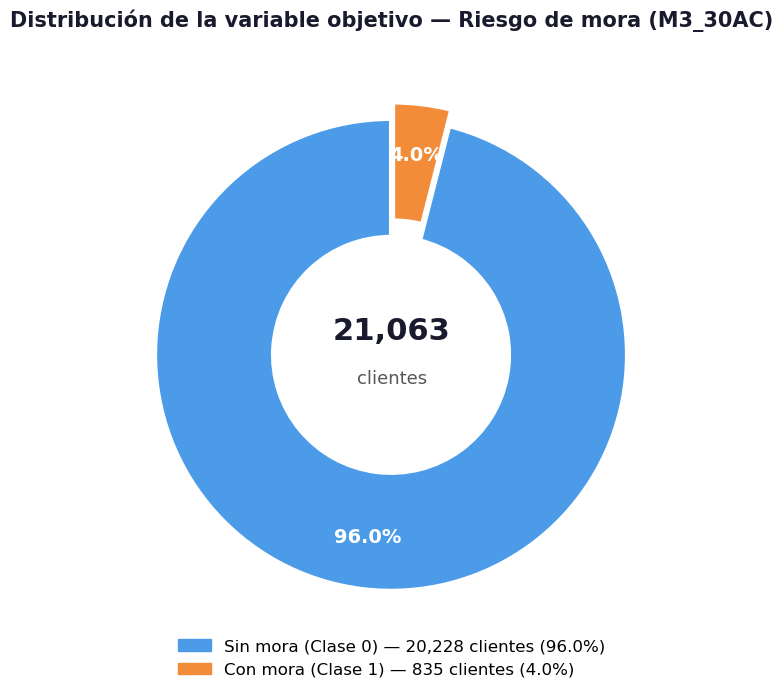

In [16]:
# ── Datos ─────────────────────────────────────────────────────────────────
conteos = df_financiacion['M3_30AC'].value_counts().sort_index()
total   = len(df_financiacion)
valores = [conteos[0], conteos[1]]
colores = ['#4C9BE8', '#F28C38']
labels  = ['Sin mora (Clase 0)', 'Con mora (Clase 1)']

# ── Figura ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    valores,
    labels=None,
    colors=colores,
    autopct='%1.1f%%',
    pctdistance=0.78,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3),
    explode=(0.02, 0.05),
    textprops=dict(fontsize=14, color='white', fontweight='bold')
)

# ── Texto central ─────────────────────────────────────────────────────────
ax.text(0, 0.08, f'{total:,}', ha='center', va='center',
        fontsize=22, fontweight='bold', color='#1a1a2e')
ax.text(0, -0.12, 'clientes', ha='center', va='center',
        fontsize=13, color='#555')

# ── Leyenda manual ────────────────────────────────────────────────────────
leyenda = [
    mpatches.Patch(color='#4C9BE8',
                   label=f'Sin mora (Clase 0) — {conteos[0]:,} clientes ({conteos[0]/total*100:.1f}%)'),
    mpatches.Patch(color='#F28C38',
                   label=f'Con mora (Clase 1) — {conteos[1]:,} clientes ({conteos[1]/total*100:.1f}%)')
]
ax.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=12, frameon=False)

# ── Título ────────────────────────────────────────────────────────────────
ax.set_title('Distribución de la variable objetivo — Riesgo de mora (M3_30AC)',
             fontsize=15, fontweight='bold', color='#1a1a2e', pad=20)

plt.tight_layout()
plt.show()

Gráfico 1 — Distribución de densidad por variable y clase:

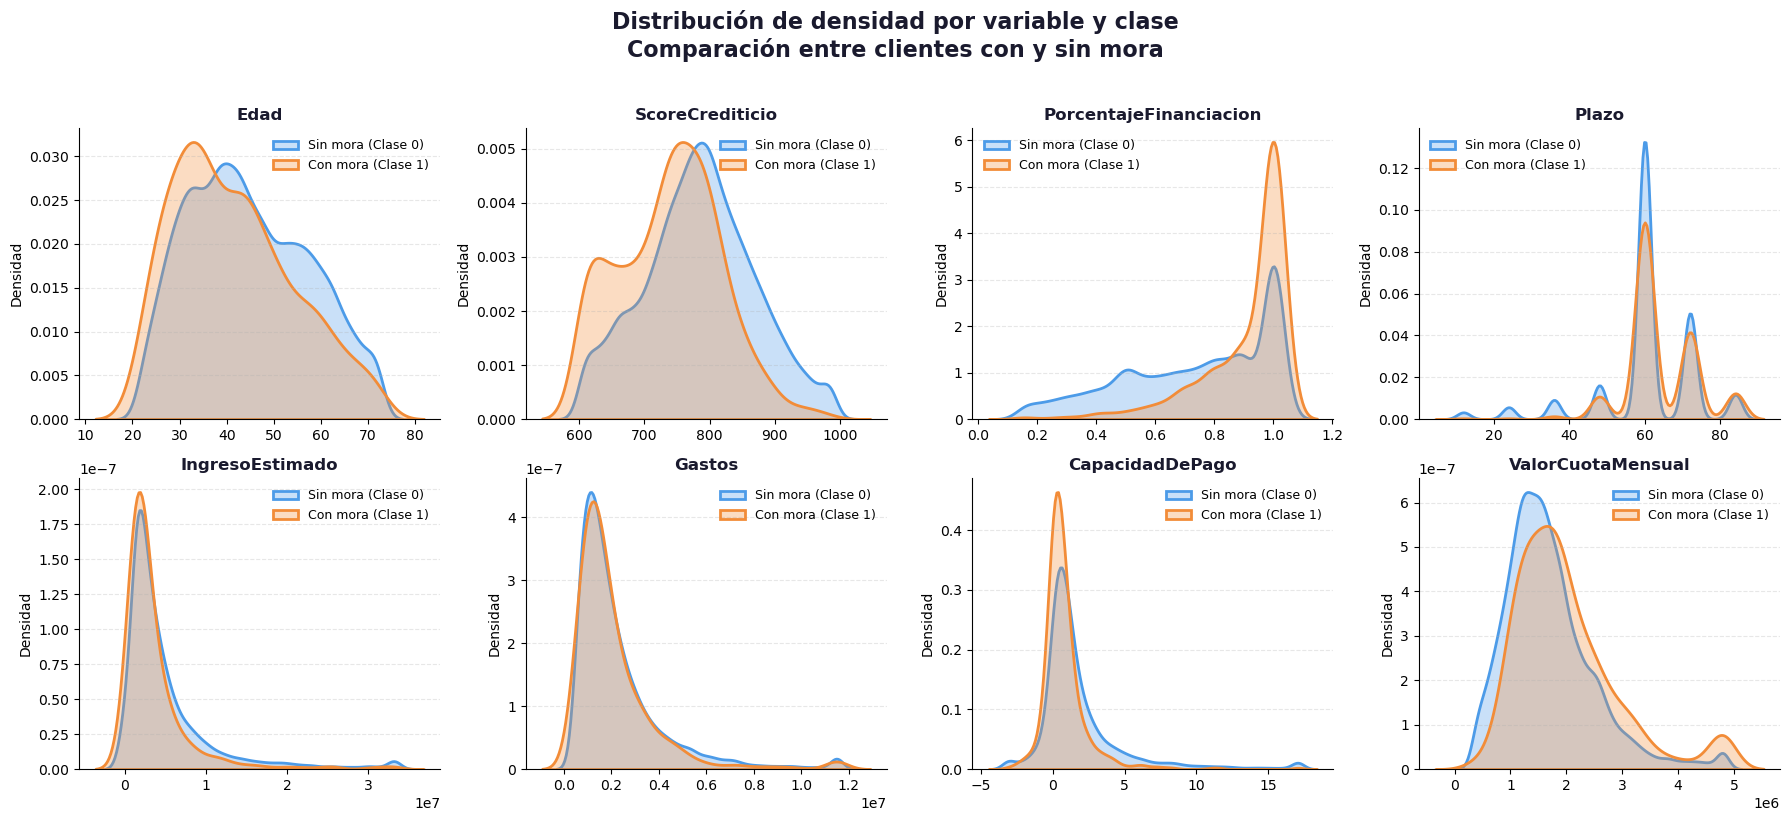

In [17]:
# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
colores    = {0: '#4C9BE8', 1: '#F28C38'}
etiquetas  = {0: 'Sin mora (Clase 0)', 1: 'Con mora (Clase 1)'}

# Clipping p1-p99 para visualización limpia
df_plot = df_financiacion.dropna().copy()
for col in variables:
    q01 = df_plot[col].quantile(0.01)
    q99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(q01, q99)

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Distribución de densidad por variable y clase\nComparación entre clientes con y sin mora',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]
    for clase in [0, 1]:
        subset = df_plot[df_plot['M3_30AC'] == clase][var]
        sns.kdeplot(subset, ax=ax, color=colores[clase],
                    label=etiquetas[clase], fill=True, alpha=0.3,
                    linewidth=2)
    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('grafico2_densidad.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 2 — Boxplot por variable y clase:

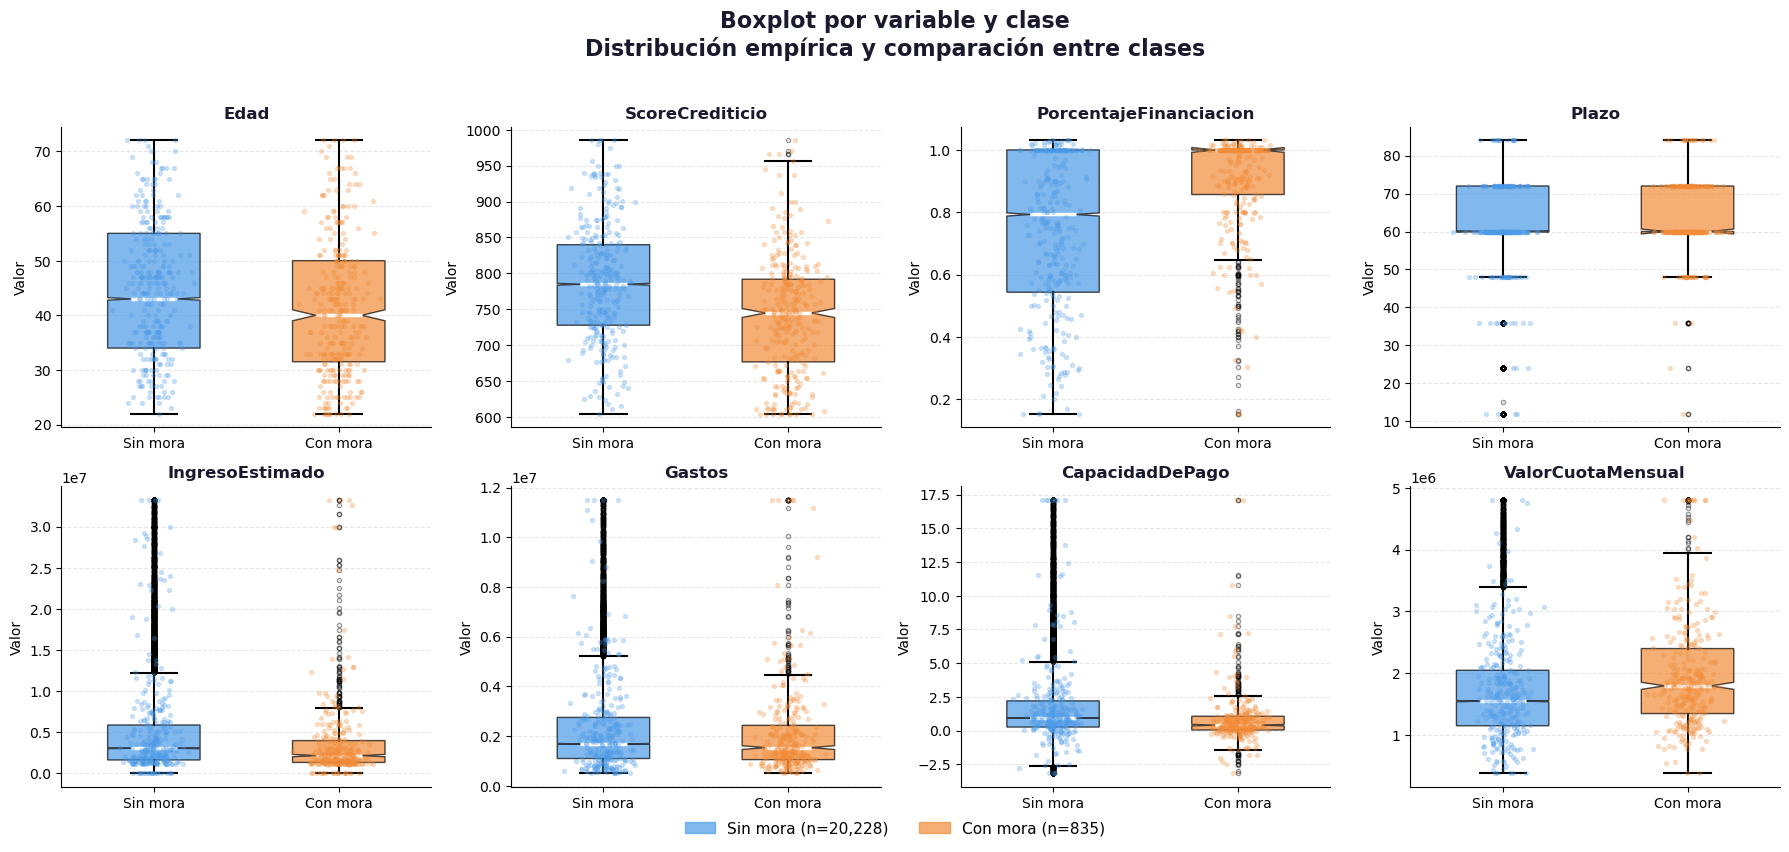

In [18]:
# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
colores    = {0: '#4C9BE8', 1: '#F28C38'}
etiquetas  = {0: 'Sin mora', 1: 'Con mora'}

# Clipping p1-p99
df_plot = df_financiacion.dropna().copy()
for col in variables:
    q01 = df_plot[col].quantile(0.01)
    q99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(q01, q99)

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Boxplot por variable y clase\nDistribución empírica y comparación entre clases',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]

    data_plot = [
        df_plot[df_plot['M3_30AC'] == 0][var].dropna(),
        df_plot[df_plot['M3_30AC'] == 1][var].dropna()
    ]

    bp = ax.boxplot(data_plot,
                    patch_artist=True,
                    notch=True,
                    vert=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    # Colores por clase
    for patch, clase in zip(bp['boxes'], [0, 1]):
        patch.set_facecolor(colores[clase])
        patch.set_alpha(0.7)

    # Overlay de puntos
    for j, (datos, clase) in enumerate(zip(data_plot, [0, 1])):
        x = np.random.normal(j + 1, 0.07, size=min(len(datos), 300))
        muestra = datos.sample(min(300, len(datos)), random_state=42)
        ax.scatter(x[:len(muestra)], muestra, alpha=0.25,
                   color=colores[clase], s=8, zorder=3)

    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sin mora', 'Con mora'], fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# ── Leyenda global ────────────────────────────────────────────────────────
leyenda = [
    mpatches.Patch(color='#4C9BE8', alpha=0.7, label=f'Sin mora (n={len(df_plot[df_plot["M3_30AC"]==0]):,})'),
    mpatches.Patch(color='#F28C38', alpha=0.7, label=f'Con mora (n={len(df_plot[df_plot["M3_30AC"]==1]):,})')
]
fig.legend(handles=leyenda, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('grafico3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()